# Experiment 1 Final Defense Report Notebook

**Experiment:** Virtual Student Agent Fidelity  
**Purpose:** Validate whether FSLSM-conditioned virtual LLM agents can reliably express assigned learning-style profiles before using them in downstream tutoring and MCP-RAG experiments.

This notebook is designed for the master's final defense report. It focuses on reusable summary tables, thesis-ready figures, and concise interpretation rather than full exploratory analysis.

In [1]:
from pathlib import Path
import json
import math
import os

LOCAL_CACHE = Path.cwd().resolve() / ".notebook-cache"
os.environ.setdefault("XDG_CACHE_HOME", str(LOCAL_CACHE))
os.environ.setdefault("MPLCONFIGDIR", str(LOCAL_CACHE / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "exp1" / "metrics").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing results/exp1/metrics")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
METRICS_DIR = PROJECT_ROOT / "results" / "exp1" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "experiments" / "exp1_agent_fidelity" / "results" / "exp1" / "final_defense_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics dir:  {METRICS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/nyeinchanaung/Documents/GitHub/mcp-rag
Metrics dir:  /Users/nyeinchanaung/Documents/GitHub/mcp-rag/results/exp1/metrics
Figures dir:  /Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures


## 1. Load Experiment 1 Metrics

The notebook uses the finalized Exp1 metric exports:

- `pra_das_summary.csv`: Profile Recovery Accuracy by model, knowledge level, and FSLSM dimension
- `das_summary.csv`: Dimension Alignment Score by model, knowledge level, and FSLSM dimension
- `baseline_natural_style.csv`: no-persona baseline learning-style tendencies
- `cost_summary.csv`: API cost summary where applicable
- `per_question_alignment.csv`: item-level ILS alignment patterns

In [2]:
df_pra = pd.read_csv(METRICS_DIR / "pra_das_summary.csv")
df_das = pd.read_csv(METRICS_DIR / "das_summary.csv")
df_baseline = pd.read_csv(METRICS_DIR / "baseline_natural_style.csv")
df_cost = pd.read_csv(METRICS_DIR / "cost_summary.csv")
df_pq = pd.read_csv(METRICS_DIR / "per_question_alignment.csv")

MODEL_META = {
    "claude-sonnet-4-20250514": {"tier": "Frontier API", "params": "Undisclosed", "type": "API"},
    "gpt-4.1-mini": {"tier": "Frontier API", "params": "Undisclosed", "type": "API"},
    "gemma3:12b": {"tier": "Open model", "params": "12B", "type": "Local"},
    "gemma2:9b": {"tier": "Open model", "params": "9B", "type": "Local"},
    "llama3.1:8b": {"tier": "Open model", "params": "8B", "type": "Local"},
    "qwen2.5:7b": {"tier": "Open model", "params": "7B", "type": "Local"},
    "mistral:7b": {"tier": "Open model", "params": "7B", "type": "Local"},
    "gemma3:4b": {"tier": "Open model", "params": "4B", "type": "Local"},
    "qwen2.5:3b": {"tier": "Open model", "params": "3B", "type": "Local"},
    "llama3.2:3b": {"tier": "Open model", "params": "3B", "type": "Local"},
    "gemma2:2b": {"tier": "Small open model", "params": "2B", "type": "Local"},
    "qwen2.5:1.5b": {"tier": "Small open model", "params": "1.5B", "type": "Local"},
    "gemma3:1b": {"tier": "Small open model", "params": "1B", "type": "Local"},
    "llama3.2:1b": {"tier": "Small open model", "params": "1B", "type": "Local"},
    "phi4-mini": {"tier": "Open model", "params": "Mini", "type": "Local"},
}

pra_overall = df_pra[(df_pra["dimension"] == "overall_4d") & (df_pra["knowledge_level"] == "ALL")][["model", "pra", "ties"]]
das_overall = df_das[(df_das["dimension"] == "overall_4d") & (df_das["knowledge_level"] == "ALL")][["model", "das"]]
summary = pra_overall.merge(das_overall, on="model", how="inner")
summary["H2_PRA_pass"] = summary["pra"] >= 0.82
summary["H2_DAS_pass"] = summary["das"] >= 0.75
summary["H2_both_pass"] = summary["H2_PRA_pass"] & summary["H2_DAS_pass"]
summary["tier"] = summary["model"].map(lambda m: MODEL_META.get(m, {}).get("tier", "Unknown"))
summary["params"] = summary["model"].map(lambda m: MODEL_META.get(m, {}).get("params", "Unknown"))
summary["type"] = summary["model"].map(lambda m: MODEL_META.get(m, {}).get("type", "Unknown"))
summary = summary.sort_values(["pra", "das"], ascending=False).reset_index(drop=True)
summary.insert(0, "rank", range(1, len(summary) + 1))

summary_display = summary[["rank", "model", "params", "type", "pra", "das", "H2_both_pass"]].copy()
summary_display.style.format({"pra": "{:.3f}", "das": "{:.3f}"})

,rank,model,params,type,pra,das,H2_both_pass
0,1,claude-sonnet-4-20250514,Undisclosed,API,1.000,0.927,True
1,2,gemma3:12b,12B,Local,1.000,0.882,True
2,3,gpt-4.1-mini,Undisclosed,API,0.996,0.924,True
3,4,qwen2.5:7b,7B,Local,0.956,0.785,True
4,5,gemma2:9b,9B,Local,0.948,0.837,True
5,6,phi4-mini,Mini,Local,0.915,0.722,False
6,7,llama3.2:3b,3B,Local,0.902,0.708,False
7,8,qwen2.5:3b,3B,Local,0.890,0.752,True
8,9,llama3.1:8b,8B,Local,0.724,0.741,False
9,10,gemma3:4b,4B,Local,0.718,0.718,False


## 2. Defense-Level Result Summary

This table condenses the main validity result. The experiment evaluates whether each LLM can preserve the assigned FSLSM profile after answering the ILS questionnaire as a virtual student agent.

In [4]:
analytics = pd.DataFrame([
    {"Measure": "Models evaluated", "Value": len(summary)},
    {"Measure": "FSLSM profiles", "Value": 16},
    {"Measure": "FSLSM agents per model", "Value": 80},
    {"Measure": "FSLSM trial records per model", "Value": 240},
    {"Measure": "Baseline no-persona records per model", "Value": 15},
    {"Measure": "Mean PRA across models", "Value": f"{summary['pra'].mean():.3f}"},
    {"Measure": "Mean DAS across models", "Value": f"{summary['das'].mean():.3f}"},
    {"Measure": "Models meeting PRA >= 0.82", "Value": int((summary['pra'] >= 0.82).sum())},
    {"Measure": "Models meeting DAS >= 0.75", "Value": int((summary['das'] >= 0.75).sum())},
    {"Measure": "Models meeting both H2 thresholds", "Value": int(summary['H2_both_pass'].sum())},
])
display(analytics)

top3 = summary.head(3)[["model", "pra", "das", "params", "type"]]
display(Markdown("### Top-performing models"))
display(top3.style.format({"pra": "{:.3f}", "das": "{:.3f}"}))

,Measure,Value
0,Models evaluated,15
1,FSLSM profiles,16
2,FSLSM agents per model,80
3,FSLSM trial records per model,240
4,Baseline no-persona records per model,15
5,Mean PRA across models,0.773
6,Mean DAS across models,0.717
7,Models meeting PRA >= 0.82,8
8,Models meeting DAS >= 0.75,6
9,Models meeting both H2 thresholds,6


### Top-performing models

,model,pra,das,params,type
0,claude-sonnet-4-20250514,1.000,0.927,Undisclosed,API
1,gemma3:12b,1.000,0.882,12B,Local
2,gpt-4.1-mini,0.996,0.924,Undisclosed,API


**Thesis interpretation:** Exp1 supports the methodological use of FSLSM-conditioned virtual student agents. Strong API models and several larger open models recovered the assigned profiles with high accuracy, while very small models clustered near chance performance. This should be framed as synthetic-agent profile fidelity, not as proof that FSLSM improves human learning outcomes.

## 3. PRA And DAS By Model

PRA measures whether the recovered FSLSM pole matches the assigned pole. DAS measures the strength of profile alignment. The shaded/threshold lines mark the hypothesis targets used in the thesis.

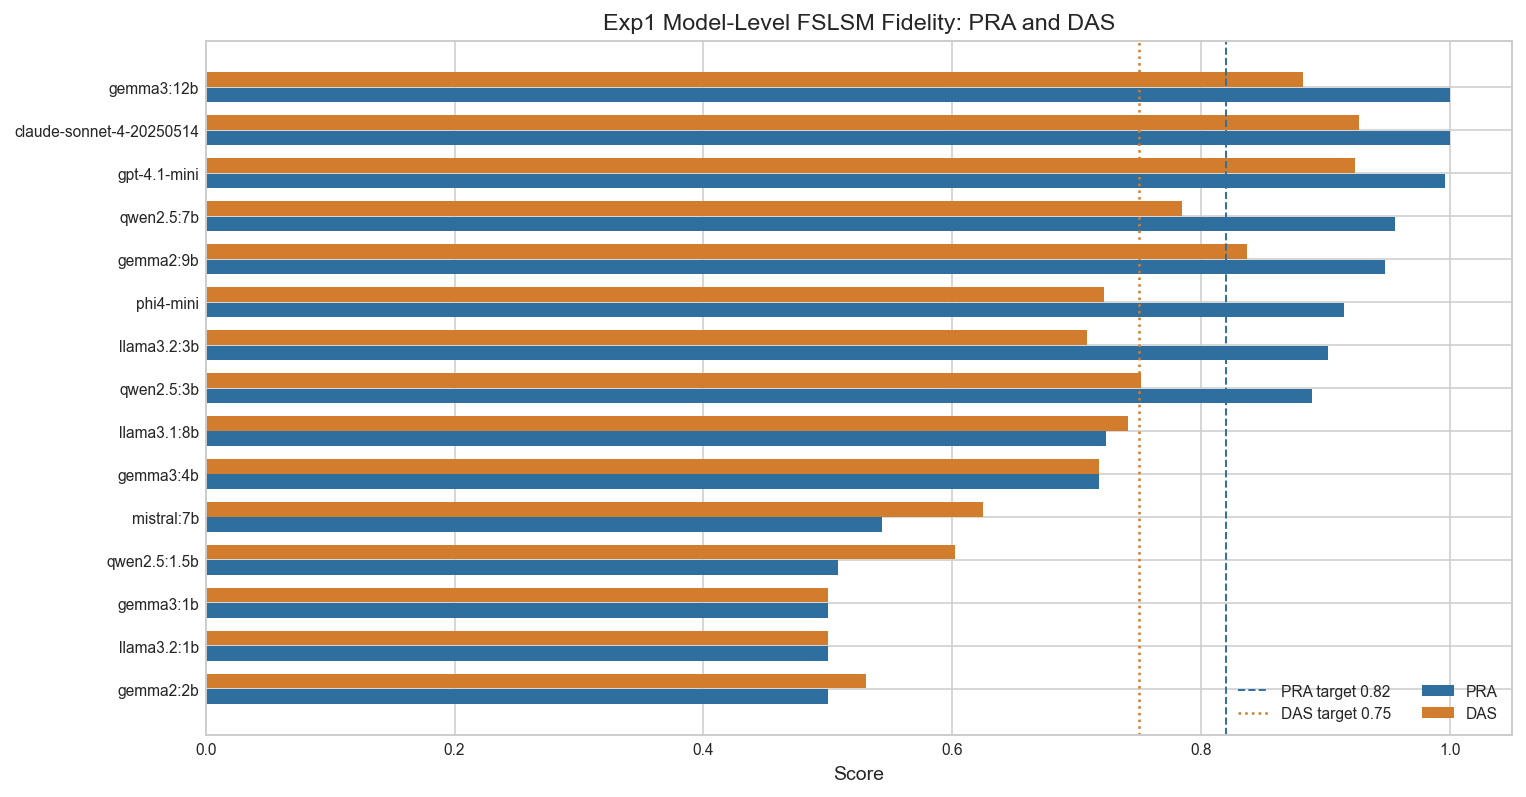

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_pra_das_by_model.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.8))
plot_df = summary.sort_values("pra", ascending=True)
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["pra"], height=0.34, label="PRA", color="#2f6f9f")
ax.barh(y + 0.18, plot_df["das"], height=0.34, label="DAS", color="#d27d2d")
ax.axvline(0.82, color="#2f6f9f", linestyle="--", linewidth=1, label="PRA target 0.82")
ax.axvline(0.75, color="#d27d2d", linestyle=":", linewidth=1.3, label="DAS target 0.75")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["model"])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Score")
ax.set_title("Exp1 Model-Level FSLSM Fidelity: PRA and DAS")
ax.legend(loc="lower right", ncol=2)
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_pra_das_by_model.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 4. H2 Target Zone

The scatter plot shows whether models satisfy both H2 thresholds. Models in the upper-right target zone meet both the PRA and DAS criteria.

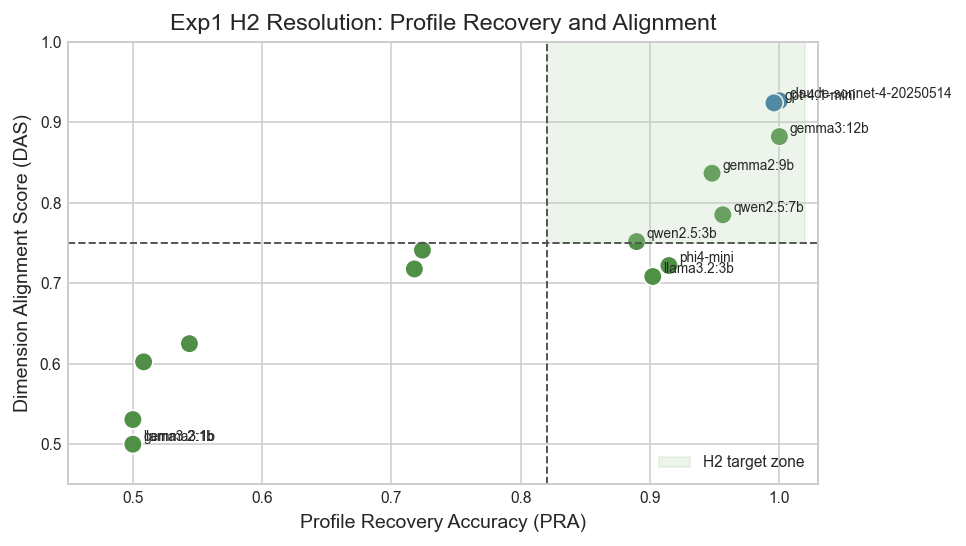

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_h2_target_zone.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = summary["type"].map({"API": "#2f6f9f", "Local": "#4f8f46"}).fillna("#777777")
ax.scatter(summary["pra"], summary["das"], s=90, c=colors, edgecolor="white", linewidth=0.8)
ax.axvline(0.82, color="#555555", linestyle="--", linewidth=1)
ax.axhline(0.75, color="#555555", linestyle="--", linewidth=1)
ax.fill_between([0.82, 1.02], 0.75, 1.02, color="#b7d7b0", alpha=0.25, label="H2 target zone")
for _, row in summary.iterrows():
    if row["rank"] <= 8 or row["model"] in ["llama3.2:1b", "gemma3:1b"]:
        ax.text(row["pra"] + 0.008, row["das"] + 0.004, row["model"], fontsize=7)
ax.set_xlim(0.45, 1.03)
ax.set_ylim(0.45, 1.0)
ax.set_xlabel("Profile Recovery Accuracy (PRA)")
ax.set_ylabel("Dimension Alignment Score (DAS)")
ax.set_title("Exp1 H2 Resolution: Profile Recovery and Alignment")
ax.legend(loc="lower right")
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_h2_target_zone.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 5. FSLSM Dimension-Level Fidelity

This heatmap identifies which FSLSM dimensions are easier or harder for each model to maintain. It is useful in the defense because it shows that the result is not only an aggregate score.

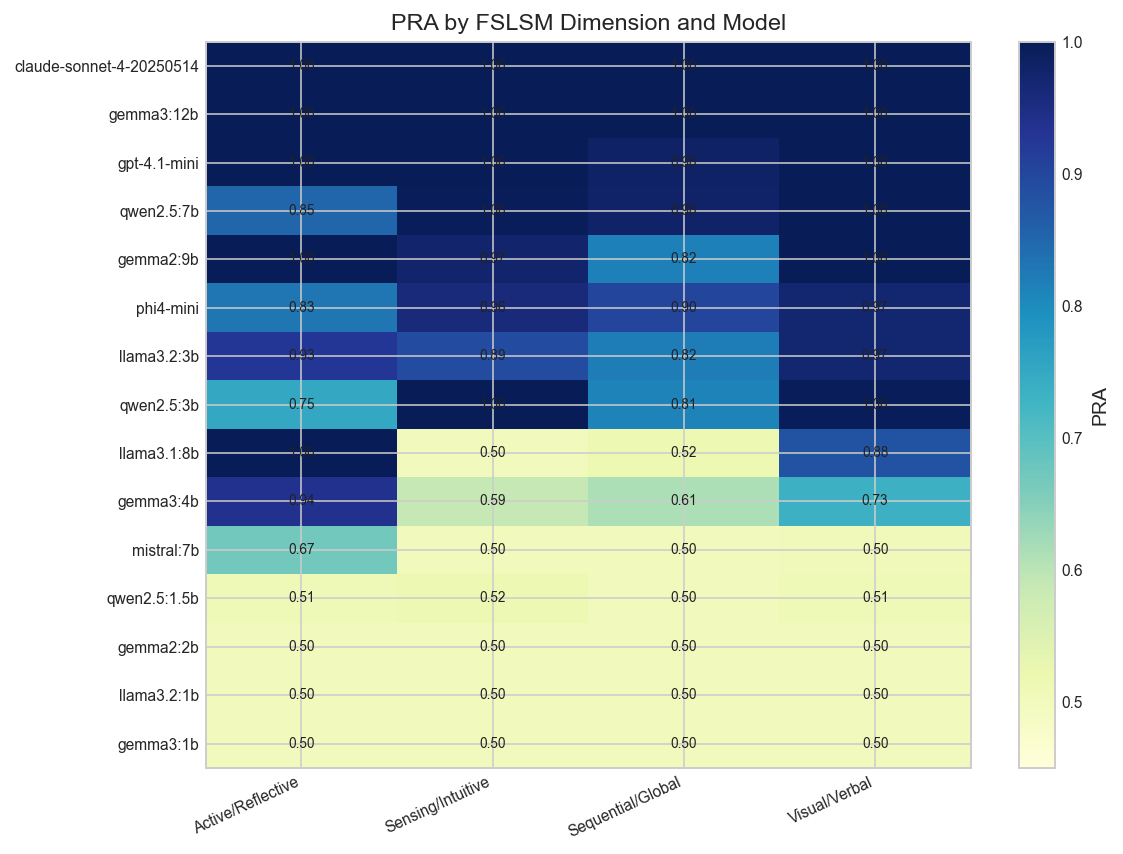

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_dimension_heatmap.png


In [7]:
DIM_LABELS = {
    "act_ref": "Active/Reflective",
    "sen_int": "Sensing/Intuitive",
    "vis_ver": "Visual/Verbal",
    "seq_glo": "Sequential/Global",
}

dim_df = df_pra[(df_pra["knowledge_level"] == "ALL") & (df_pra["dimension"] != "overall_4d")]
dim_pivot = dim_df.pivot(index="model", columns="dimension", values="pra").loc[summary["model"]]
dim_pivot = dim_pivot.rename(columns=DIM_LABELS)

fig, ax = plt.subplots(figsize=(8.5, 6.2))
im = ax.imshow(dim_pivot.values, aspect="auto", cmap="YlGnBu", vmin=0.45, vmax=1.0)
ax.set_xticks(np.arange(dim_pivot.shape[1]))
ax.set_xticklabels(dim_pivot.columns, rotation=25, ha="right")
ax.set_yticks(np.arange(dim_pivot.shape[0]))
ax.set_yticklabels(dim_pivot.index)
for i in range(dim_pivot.shape[0]):
    for j in range(dim_pivot.shape[1]):
        ax.text(j, i, f"{dim_pivot.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7, color="#222")
ax.set_title("PRA by FSLSM Dimension and Model")
fig.colorbar(im, ax=ax, label="PRA")
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_dimension_heatmap.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 6. Knowledge-Level Robustness

The experiment also tested beginner, intermediate, advanced, and general prompts. This chart checks whether profile fidelity remains stable across content difficulty levels.

,knowledge_level,mean,std,min,max
0,beginner,0.764,0.209,0.500,1.000
1,intermediate,0.773,0.212,0.500,1.000
2,advanced,0.775,0.211,0.500,1.000
3,general,0.777,0.211,0.500,1.000


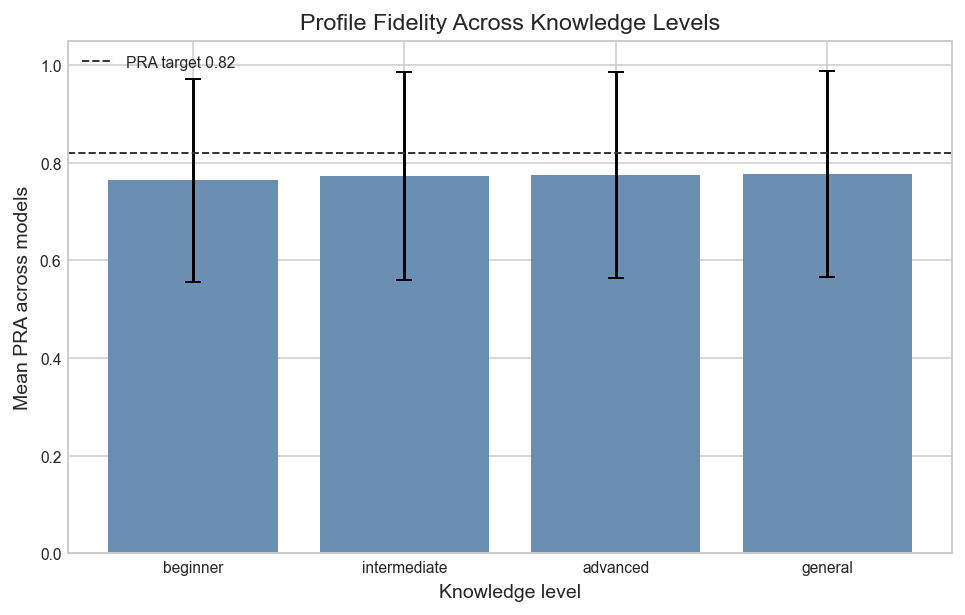

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_knowledge_level_pra.png


In [8]:
kl_order = ["beginner", "intermediate", "advanced", "general"]
kl_df = df_pra[(df_pra["dimension"] == "overall_4d") & (df_pra["knowledge_level"] != "ALL")].copy()
kl_df["knowledge_level"] = pd.Categorical(kl_df["knowledge_level"], categories=kl_order, ordered=True)
kl_summary = kl_df.groupby("knowledge_level", observed=True)["pra"].agg(["mean", "std", "min", "max"]).reset_index()

display(kl_summary.style.format({"mean": "{:.3f}", "std": "{:.3f}", "min": "{:.3f}", "max": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(kl_summary["knowledge_level"].astype(str), kl_summary["mean"], yerr=kl_summary["std"], capsize=4, color="#6b8fb3")
ax.axhline(0.82, color="#333333", linestyle="--", linewidth=1, label="PRA target 0.82")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean PRA across models")
ax.set_xlabel("Knowledge level")
ax.set_title("Profile Fidelity Across Knowledge Levels")
ax.legend()
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_knowledge_level_pra.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 7. Baseline Natural Style Without Persona Conditioning

The no-persona baseline checks whether models naturally converge to a particular FSLSM style without profile instructions. This is important because Exp1 needs to show that high fidelity comes from profile conditioning, not merely from a model's default response preference.

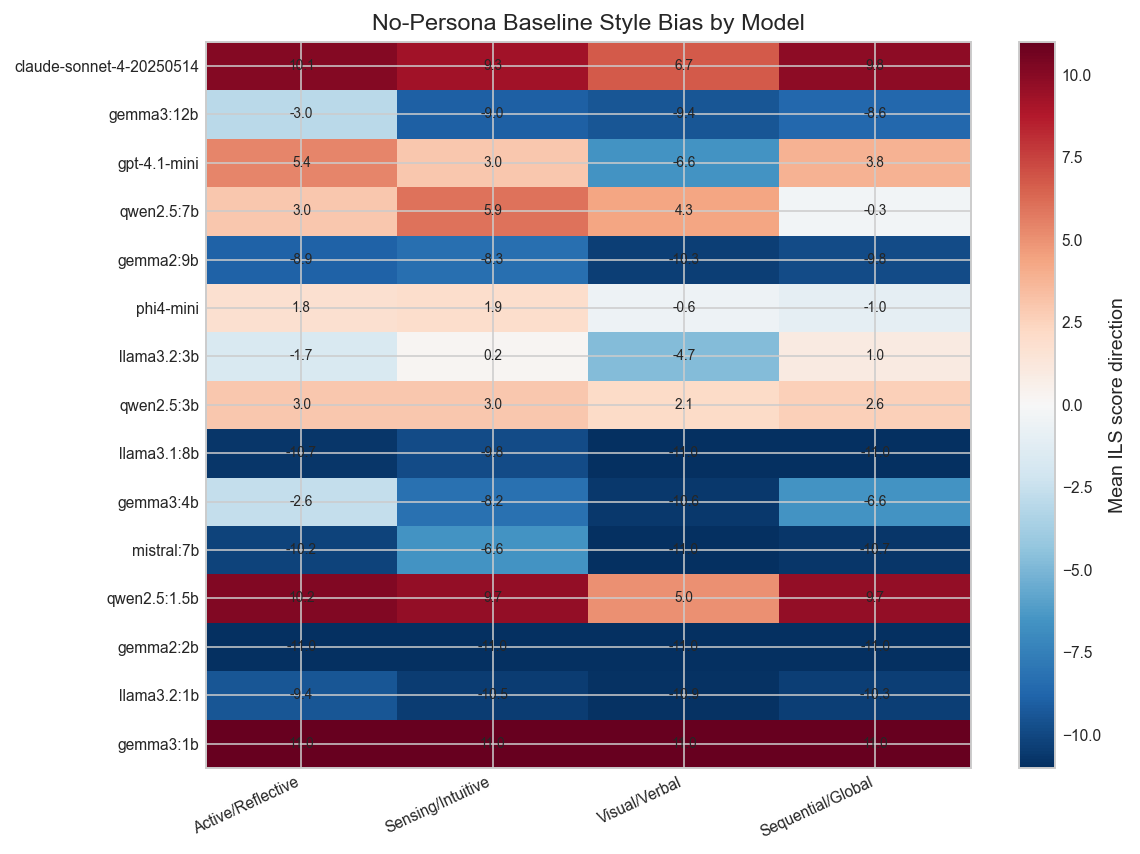

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_baseline_bias_heatmap.png


In [9]:
baseline_cols = ["act_ref_mean_score", "sen_int_mean_score", "vis_ver_mean_score", "seq_glo_mean_score"]
baseline_labels = ["Active/Reflective", "Sensing/Intuitive", "Visual/Verbal", "Sequential/Global"]
baseline_matrix = df_baseline.set_index("model")[baseline_cols].loc[summary["model"]]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
limit = max(abs(baseline_matrix.min().min()), abs(baseline_matrix.max().max()))
im = ax.imshow(baseline_matrix.values, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(np.arange(len(baseline_labels)))
ax.set_xticklabels(baseline_labels, rotation=25, ha="right")
ax.set_yticks(np.arange(len(baseline_matrix.index)))
ax.set_yticklabels(baseline_matrix.index)
for i in range(baseline_matrix.shape[0]):
    for j in range(baseline_matrix.shape[1]):
        ax.text(j, i, f"{baseline_matrix.iloc[i, j]:.1f}", ha="center", va="center", fontsize=7)
ax.set_title("No-Persona Baseline Style Bias by Model")
fig.colorbar(im, ax=ax, label="Mean ILS score direction")
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_baseline_bias_heatmap.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 8. Item-Level Failure Pattern

The hardest ILS items reveal where profile expression is least stable. This supports a limitations-aware discussion: some questionnaire items are more ambiguous or more difficult for smaller models.

,q_num,dimension,mean_alignment_rate
39,40,Sequential/Global,0.535
41,42,Sensing/Intuitive,0.538
15,16,Sequential/Global,0.552
43,44,Sequential/Global,0.565
25,26,Sensing/Intuitive,0.602
29,30,Sensing/Intuitive,0.614
11,12,Sequential/Global,0.614
21,22,Sensing/Intuitive,0.620
27,28,Sequential/Global,0.622
7,8,Sequential/Global,0.626


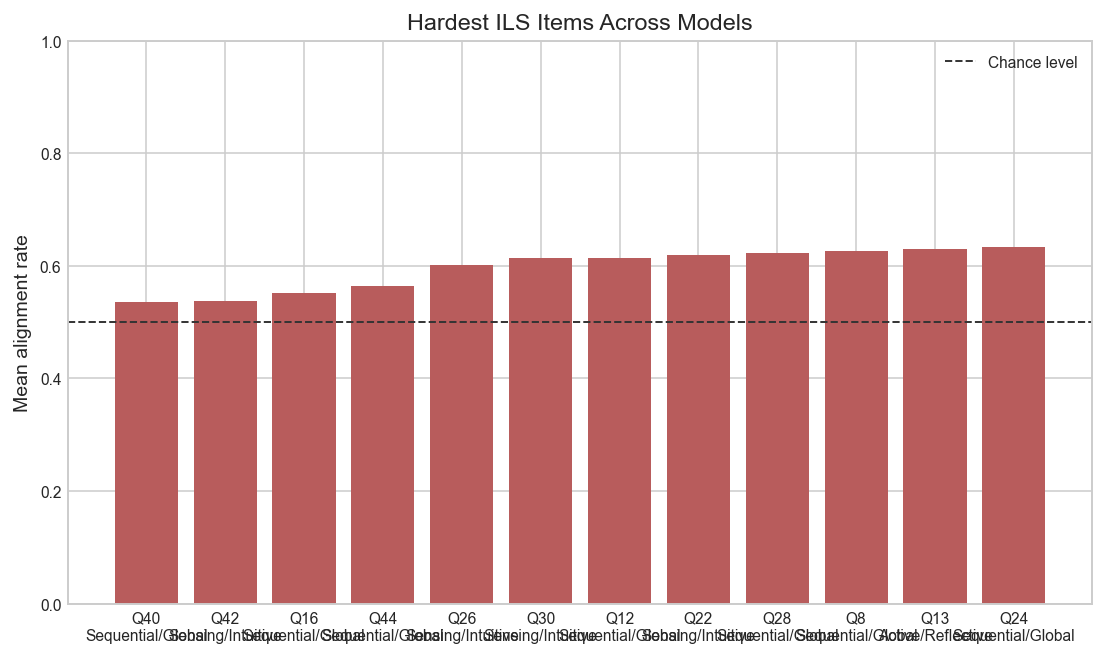

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_hardest_items.png


In [10]:
question_summary = (
    df_pq.groupby(["q_num", "dimension"], as_index=False)["alignment_rate"]
    .mean()
    .rename(columns={"alignment_rate": "mean_alignment_rate"})
    .sort_values("mean_alignment_rate")
)
hardest = question_summary.head(12).copy()
hardest["dimension"] = hardest["dimension"].map(DIM_LABELS)
display(hardest.style.format({"mean_alignment_rate": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(8, 4.8))
labels = [f"Q{int(r.q_num)}\n{r.dimension}" for r in hardest.itertuples()]
ax.bar(labels, hardest["mean_alignment_rate"], color="#b85c5c")
ax.axhline(0.50, color="#333333", linestyle="--", linewidth=1, label="Chance level")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Mean alignment rate")
ax.set_title("Hardest ILS Items Across Models")
ax.legend()
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_hardest_items.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 9. Cost Versus Fidelity

This chart is useful for methodological justification. It shows that `gpt-4.1-mini` provides near-frontier fidelity at much lower API cost than the larger frontier model, while local models have no API cost but vary substantially in fidelity.

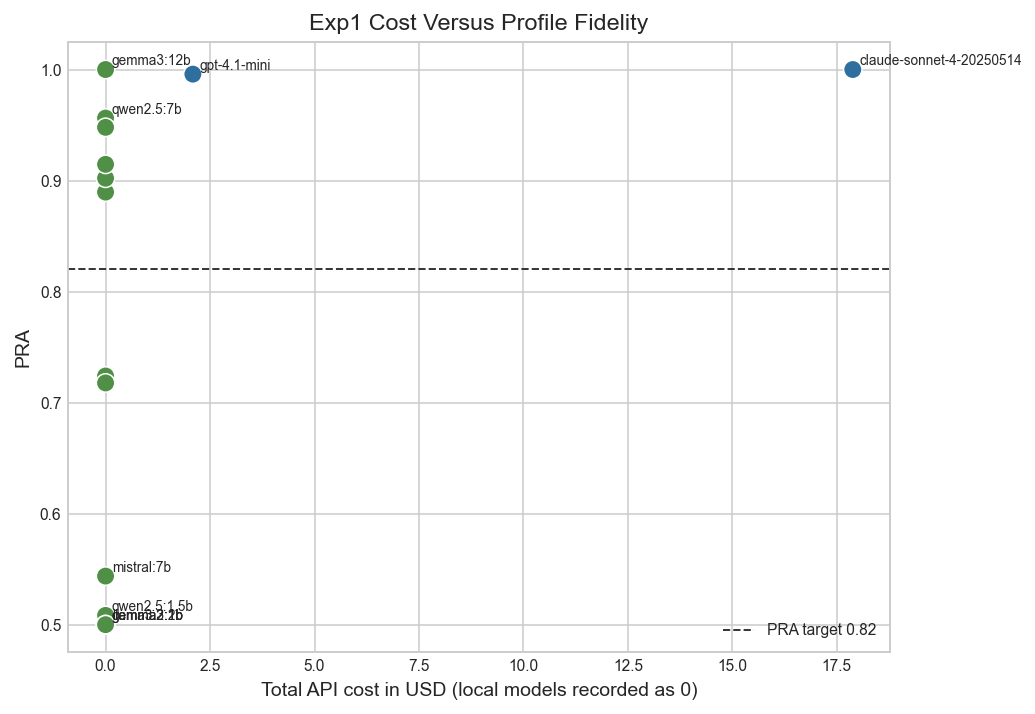

/Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp1_agent_fidelity/results/exp1/final_defense_figures/exp1_defense_cost_vs_pra.png


In [11]:
cost_main = df_cost[~df_cost["model"].str.contains("baseline", case=False, na=False)].copy()
cost_main = cost_main.merge(summary[["model", "pra", "das", "type"]], on="model", how="inner")

fig, ax = plt.subplots(figsize=(7.5, 5.2))
colors = cost_main["type"].map({"API": "#2f6f9f", "Local": "#4f8f46"}).fillna("#777777")
ax.scatter(cost_main["total_usd"], cost_main["pra"], s=90, c=colors, edgecolor="white", linewidth=0.8)
for _, row in cost_main.iterrows():
    if row["total_usd"] > 0 or row["pra"] >= 0.95 or row["pra"] <= 0.55:
        ax.text(row["total_usd"] + 0.15, row["pra"] + 0.004, row["model"], fontsize=7)
ax.axhline(0.82, color="#333333", linestyle="--", linewidth=1, label="PRA target 0.82")
ax.set_xlabel("Total API cost in USD (local models recorded as 0)")
ax.set_ylabel("PRA")
ax.set_title("Exp1 Cost Versus Profile Fidelity")
ax.legend(loc="lower right")
fig.tight_layout()
out = FIGURES_DIR / "exp1_defense_cost_vs_pra.png"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(out)

## 10. Defense-Ready Interpretation

Use the following points in the final report or oral defense:

1. **Validation role:** Exp1 is a validation experiment. It establishes whether virtual LLM agents can reliably instantiate assigned FSLSM profiles before those agents are used in later tutoring experiments.
2. **Hypothesis outcome:** H2 is supported for the stronger model group. Eight models pass the PRA threshold, and six pass both PRA and DAS thresholds.
3. **Model capability pattern:** Strong API models and larger open models show high profile fidelity. Very small models remain close to chance-level profile recovery.
4. **Baseline control:** No-persona baseline responses show stable natural style tendencies, but they do not explain the high profile recovery achieved by FSLSM-conditioned agents.
5. **Limitation:** The result validates synthetic FSLSM profile fidelity under the selected questionnaire and prompt protocol. It does not prove that FSLSM categories improve real learner outcomes.

In [12]:
figure_files = sorted(FIGURES_DIR.glob("*.png"))
figure_index = pd.DataFrame({
    "figure_file": [p.name for p in figure_files],
    "path": [str(p.relative_to(PROJECT_ROOT)) for p in figure_files],
})
display(Markdown("### Generated figure files"))
display(figure_index)

### Generated figure files

,figure_file,path
0,exp1_defense_baseline_bias_heatmap.png,experiments/exp1_agent_fidelity/results/exp1/f...
1,exp1_defense_cost_vs_pra.png,experiments/exp1_agent_fidelity/results/exp1/f...
2,exp1_defense_dimension_heatmap.png,experiments/exp1_agent_fidelity/results/exp1/f...
3,exp1_defense_h2_target_zone.png,experiments/exp1_agent_fidelity/results/exp1/f...
4,exp1_defense_hardest_items.png,experiments/exp1_agent_fidelity/results/exp1/f...
5,exp1_defense_knowledge_level_pra.png,experiments/exp1_agent_fidelity/results/exp1/f...
6,exp1_defense_pra_das_by_model.png,experiments/exp1_agent_fidelity/results/exp1/f...
